In [91]:
import os
import pandas as pd
import importlib.resources as pkg_resources
from build_database.__main__ import main
from phreeqpython import PhreeqPython
import sys
import tests
import numpy as np
import matplotlib.pyplot as plt

In [92]:
# find the path to the phreeqc database
db_paths = pkg_resources.files('build_database').joinpath('databases')
db_list = []
for file in os.listdir(db_paths):
    if file.endswith('.dat'):
        db_list.append(os.path.join(db_paths, file))
for i, db in enumerate(db_list):
    print(f'{i}: {db}')

master_path = pkg_resources.files('build_database').joinpath('master_database.dat')
if not os.path.exists(master_path):
    print(f'{master_path} not found. Run build_database first')
    raise FileNotFoundError(f'{master_path} not found')

0: /home/jjl122/repos/irp-jjl122/build_database/databases/llnl.dat
1: /home/jjl122/repos/irp-jjl122/build_database/databases/Tipping_Hurley.dat
2: /home/jjl122/repos/irp-jjl122/build_database/databases/wateq4f.dat
3: /home/jjl122/repos/irp-jjl122/build_database/databases/phreeqc.dat
4: /home/jjl122/repos/irp-jjl122/build_database/databases/sit.dat
5: /home/jjl122/repos/irp-jjl122/build_database/databases/pitzer.dat
6: /home/jjl122/repos/irp-jjl122/build_database/databases/minteq.v4.dat


In [93]:
def example(db: str):
    pp = PhreeqPython(db)
    val = 'output.xls'
    keep = ['AsO4-3', 'HAsO4-2', 'H2AsO4-', 'H3AsO4']
    # CHANGE THIS TO THE PATH TO THE OUTPUT FILE
    val_path = '/home/jjl122/repos/irp-jjl122/tests/output.xls'
    df_val = pd.read_csv(val_path, sep='\t')
    df_val.columns = [c.replace('m_', '').strip() for c in df_val.columns]
    df_val.set_index('pH', inplace=True)
    df_val = df_val[keep]
    result = pd.DataFrame()
    for pH in df_val.index:
        sol = {
            'units': 'mol/kgw',
            'pH': pH,
            'Cl': 0.1,
            'Na': 0.1,
            'As(+5)': 0.0000030,
        }
        solution = pp.add_solution(sol)
        temp_df = pd.DataFrame(solution.species, index=[pH])
        result = pd.concat([result, temp_df])

    result = result[keep]
    result.index.name = 'pH'
    result.head()
    try:
        pd.testing.assert_frame_equal(result, df_val)
        return None, None
    except AssertionError:
        return result, df_val

In [94]:
example(db_list[0])

(None, None)

In [95]:
example_1_results, example_1_val = example(master_path)

In [96]:
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.facecolor': '#eeeeee',
    'axes.facecolor': '#eeeeee',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300  # High resolution for publication
})

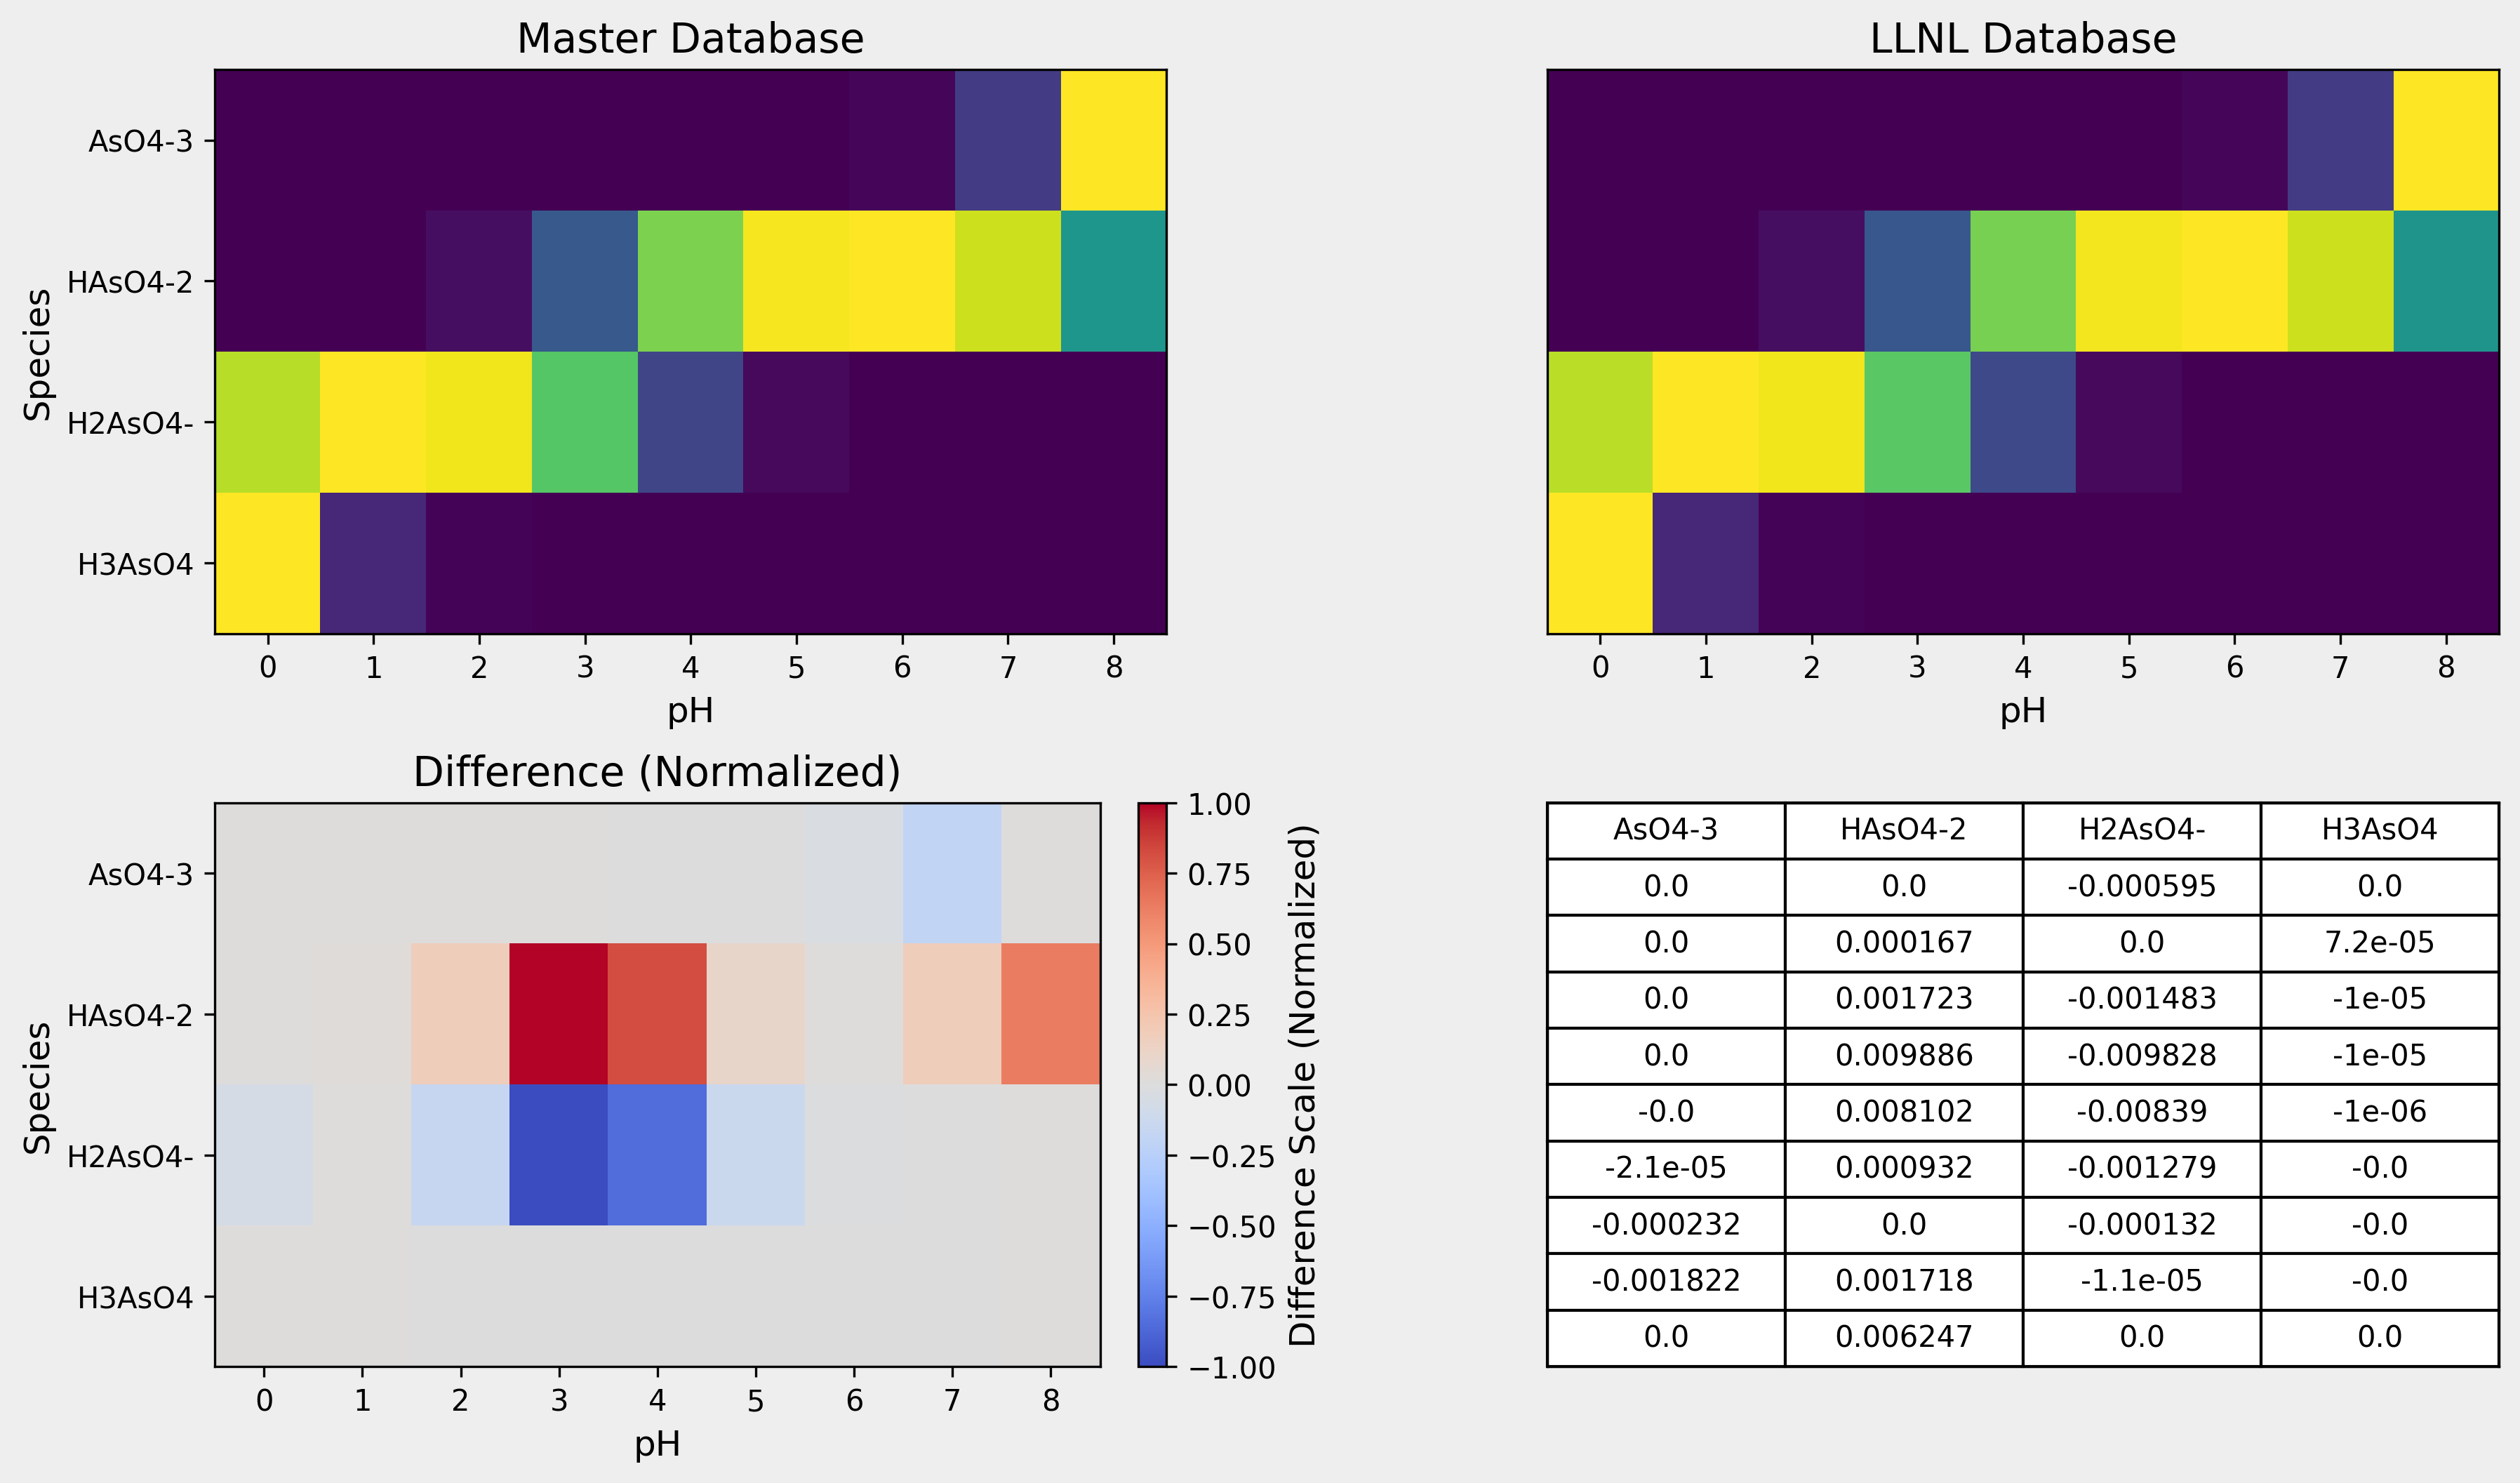

In [97]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define the rescale function
def rescale(df):
    return (df - df.min()) / (df.max() - df.min())

# Rescale the data
example_1_results = rescale(example_1_results)
example_1_val = rescale(example_1_val)

# Calculate the signed difference
diff = example_1_results - example_1_val

# Normalize the difference to the range of -1 to 1 (Optional but can enhance visibility of subtle differences)
max_diff = max(abs(diff.min().min()), abs(diff.max().max()))
diff_normalized = diff / max_diff

# Create a figure with GridSpec for flexible subplot arrangement
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])  # Adjusted to 2 rows and 2 columns

# First subplot (top left)
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(example_1_results.T, cmap='viridis', aspect='auto')
ax1.set_title('Master Database')
ax1.set_xlabel('pH')
ax1.set_ylabel('Species')
ax1.set_yticks(np.arange(len(example_1_results.columns)))
ax1.set_yticklabels(example_1_results.columns)

# Second subplot (top right)
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(example_1_val.T, cmap='viridis', aspect='auto')
ax2.set_title('LLNL Database')
ax2.set_xlabel('pH')
ax2.set_yticks([])

# Third subplot (bottom left)
ax3 = fig.add_subplot(gs[1, 0])
im = ax3.imshow(diff_normalized.T, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax3.set_title('Difference (Normalized)')
ax3.set_xlabel('pH')
ax3.set_ylabel('Species')
ax3.set_yticks(np.arange(len(diff.columns)))
ax3.set_yticklabels(diff.columns)

# Add color bar for the bottom left heatmap
cbar = fig.colorbar(im, ax=ax3, orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Difference Scale (Normalized)')

# Fourth subplot (bottom right) for DataFrame display
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')  # Turn off the axis

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('tight')  # Adjust the axis for the table display

# Create table with adjusted bounding box and font size
table = ax4.table(
    cellText=diff.values.round(6),
    colLabels=diff.columns,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]  # Adjust the bounding box to fit the table better within the subplot
)

# Adjust table properties for better fit
table.auto_set_font_size(False)
table.set_fontsize(10)  # Smaller font size to fit better
table.scale(0.8, 0.8)  # Scale down the table size
# turn the y x axis of and setthe x axis as values from 0-8
ax4.get_xaxis().set_visible(False)
ax4.get_yaxis().set_visible(False)

# Adjust layout for better spacing
plt.subplots_adjust(hspace=0.3, wspace=0.4)

plt.show()


In [98]:
db_list

['/home/jjl122/repos/irp-jjl122/build_database/databases/llnl.dat',
 '/home/jjl122/repos/irp-jjl122/build_database/databases/Tipping_Hurley.dat',
 '/home/jjl122/repos/irp-jjl122/build_database/databases/wateq4f.dat',
 '/home/jjl122/repos/irp-jjl122/build_database/databases/phreeqc.dat',
 '/home/jjl122/repos/irp-jjl122/build_database/databases/sit.dat',
 '/home/jjl122/repos/irp-jjl122/build_database/databases/pitzer.dat',
 '/home/jjl122/repos/irp-jjl122/build_database/databases/minteq.v4.dat']

/home/jjl122/repos/irp-jjl122/build_database/databases/Tipping_Hurley.dat


/home/jjl122/repos/irp-jjl122/build_database/databases/wateq4f.dat

In [99]:
e1_th, _ = example(db_list[1])
# Rescale the data
e1_th = rescale(e1_th)
diff = e1_th - example_1_val

# Normalize the difference to the range of -1 to 1 (Optional but can enhance visibility of subtle differences)
max_diff = max(abs(diff.min().min()), abs(diff.max().max()))
diff_normalized = diff / max_diff

In [100]:
e1_w, _ = example(db_list[2])
# Rescale the data
e1_w = rescale(e1_w)
diff = e1_w - example_1_val

# Normalize the difference to the range of -1 to 1 (Optional but can enhance visibility of subtle differences)
max_diff = max(abs(diff.min().min()), abs(diff.max().max()))
diff_normalized_1 = diff / max_diff

In [107]:
e1_th.columns

Index(['AsO4-3', 'HAsO4-2', 'H2AsO4-', 'H3AsO4'], dtype='object')

/tmp/ipykernel_51149/2323524230.py:12: UserWarning: Adding colorbar to a different Figure <Figure size 4200x1800 with 4 Axes> than <Figure size 4200x1800 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(im, ax=axs[0], orientation='vertical', fraction=0.03, pad=0.04)


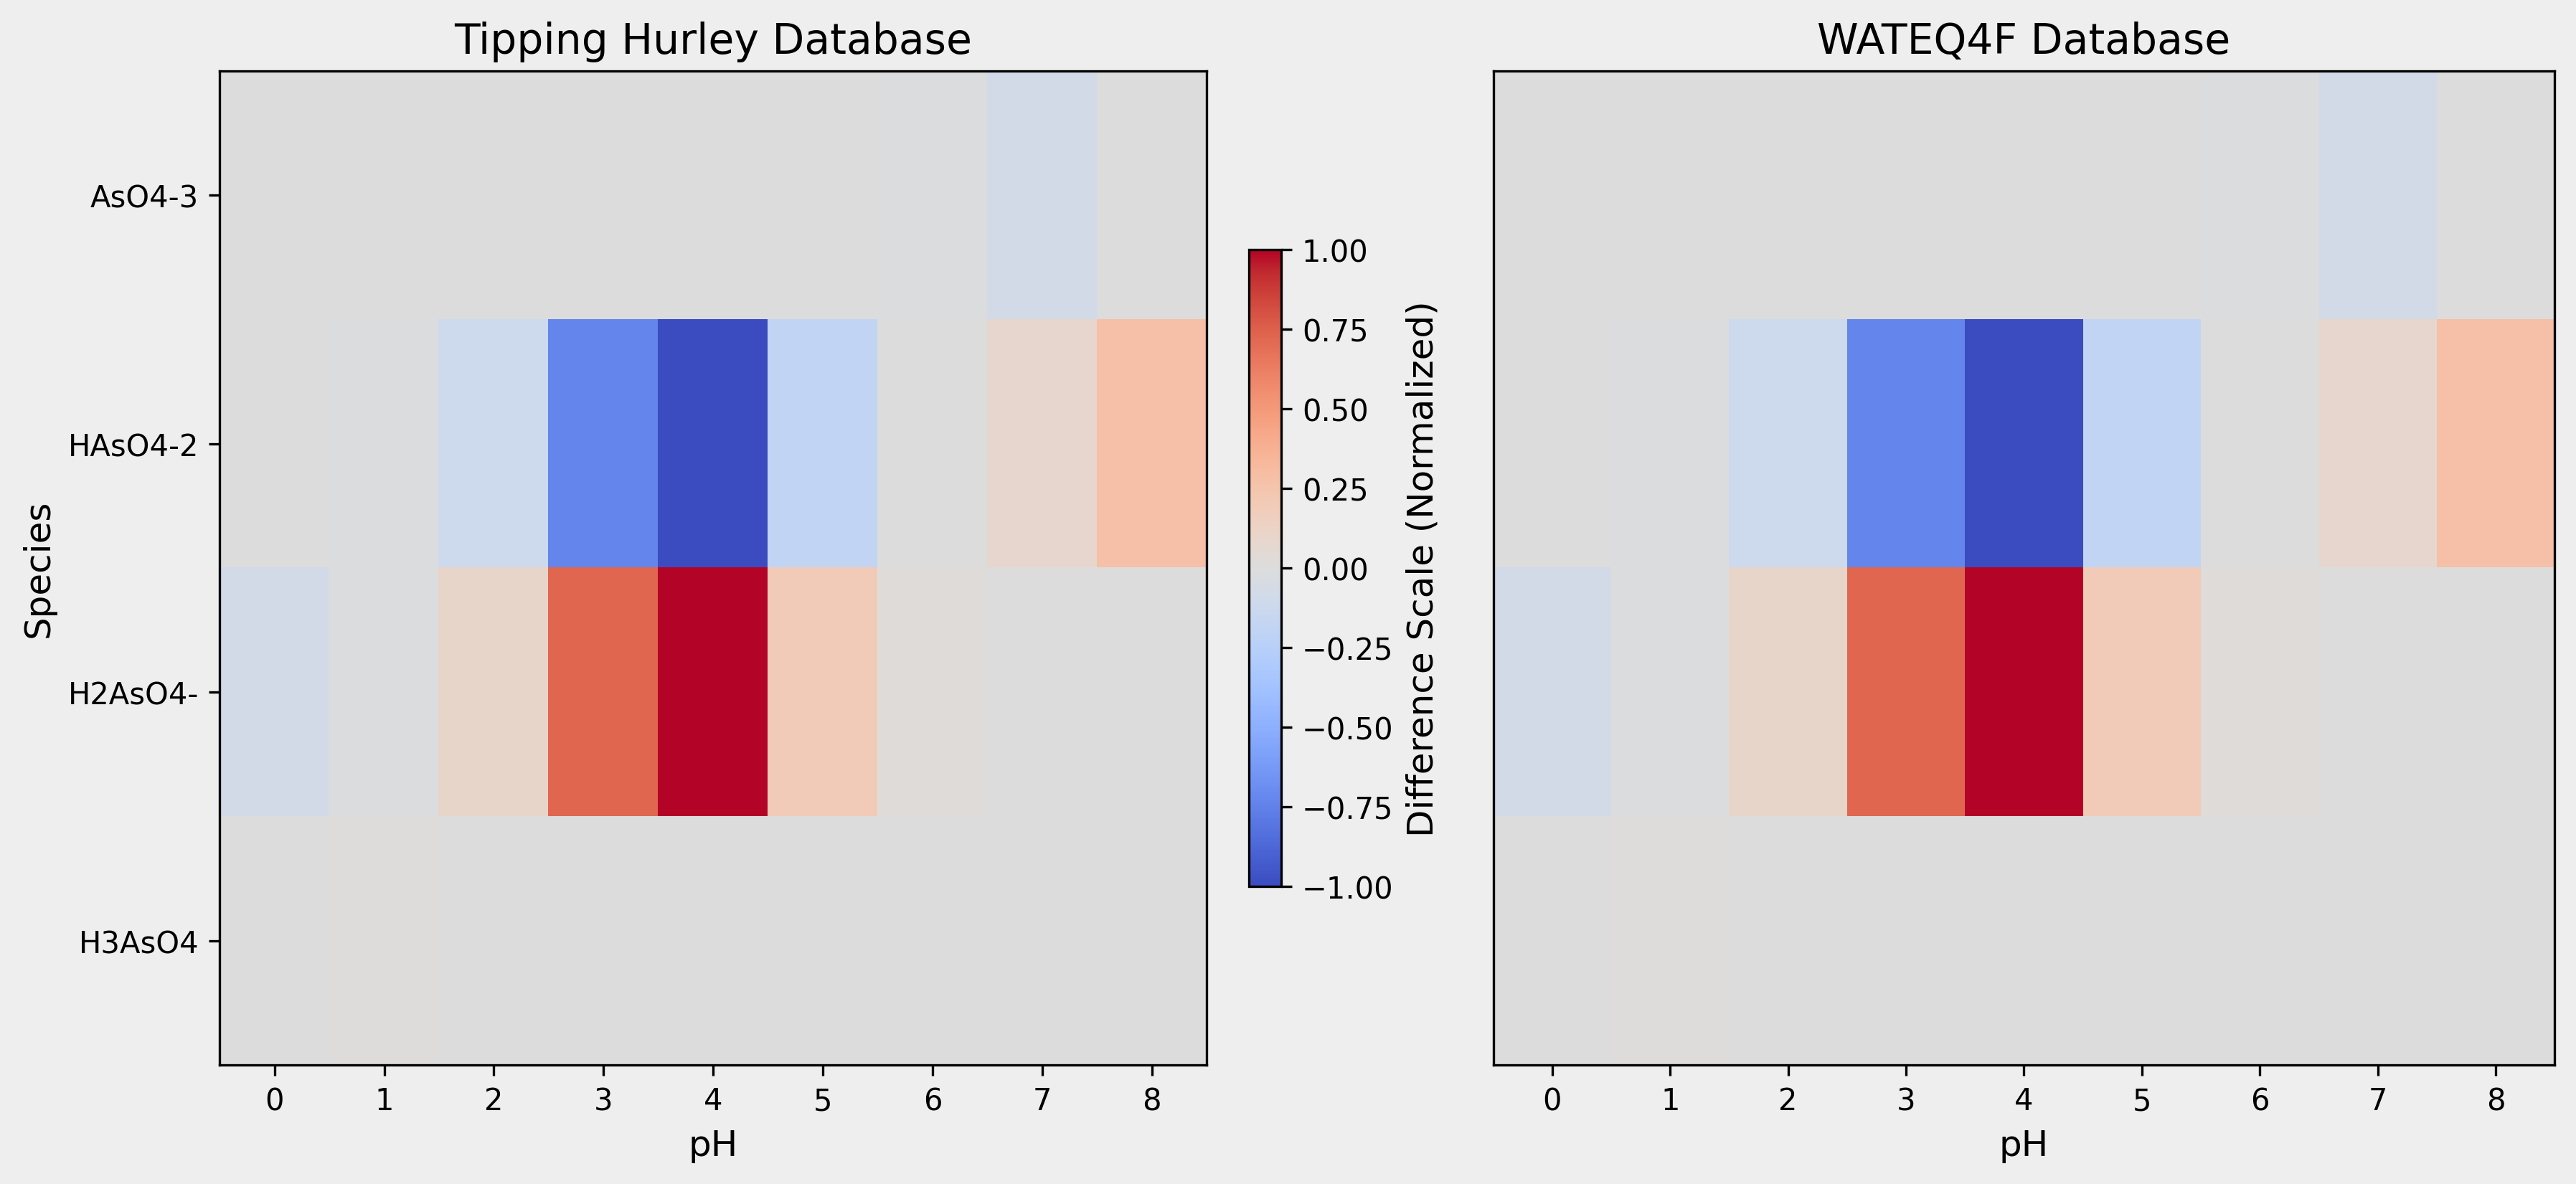

In [118]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].imshow(diff_normalized.T, cmap='coolwarm', aspect='auto')
axs[0].set_title('Tipping Hurley Database')
axs[0].set_xlabel('pH')
axs[0].set_ylabel('Species')
axs[0].set_yticks(np.arange(len(diff.columns)))
axs[0].set_yticklabels(diff.columns)
axs[1].imshow(diff_normalized_1.T, cmap='coolwarm', aspect='auto')
axs[1].set_title('WATEQ4F Database')
axs[1].set_xlabel('pH')
axs[1].set_yticks([])
cbar = fig.colorbar(im, ax=axs[0], orientation='vertical', fraction=0.03, pad=0.04)
cbar.set_label('Difference Scale (Normalized)')

In [102]:
# Third subplot (bottom left)
ax3 = fig.add_subplot(gs[1, 0])
im = ax3.imshow(diff_normalized.T, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax3.set_title('Difference (Normalized)')
ax3.set_xlabel('pH')
ax3.set_ylabel('Species')
ax3.set_yticks(np.arange(len(diff.columns)))
ax3.set_yticklabels(diff.columns)

[Text(0, 0, 'AsO4-3'),
 Text(0, 1, 'HAsO4-2'),
 Text(0, 2, 'H2AsO4-'),
 Text(0, 3, 'H3AsO4')]